In [15]:
#Run in terminal
#pip install medmnist

In [16]:
#Packages
from medmnist import RetinaMNIST
import pandas as pd
import numpy as np
import PIL
import torch
import torchvision
import torchvision.transforms as transforms
from torchvision.transforms import v2
import matplotlib.pyplot as plt
from collections import Counter
import torchvision.transforms as transforms
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt


Dataset RetinaMNIST of size 28 (retinamnist)
    Number of datapoints: 1080
    Root location: C:\Users\tyenc\.medmnist
    Split: train
    Task: ordinal-regression
    Number of channels: 3
    Meaning of labels: {'0': '0', '1': '1', '2': '2', '3': '3', '4': '4'}
    Number of samples: {'train': 1080, 'val': 120, 'test': 400}
    Description: The RetinaMNIST is based on the DeepDRiD challenge, which provides a dataset of 1,600 retina fundus images. The task is ordinal regression for 5-level grading of diabetic retinopathy severity. We split the source training set with a ratio of 9:1 into training and validation set, and use the source validation set as the test set. The source images of 3×1,736×1,824 are center-cropped and resized into 3×28×28.
    License: CC BY 4.0


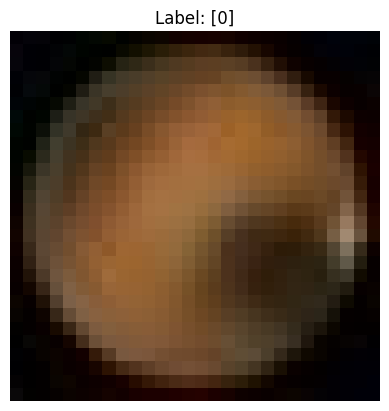


TRAIN split:
  Label 0: 486 images
  Label 1: 128 images
  Label 2: 206 images
  Label 3: 194 images
  Label 4: 66 images

VAL split:
  Label 0: 54 images
  Label 1: 12 images
  Label 2: 28 images
  Label 3: 20 images
  Label 4: 6 images

TEST split:
  Label 0: 174 images
  Label 1: 46 images
  Label 2: 92 images
  Label 3: 68 images
  Label 4: 20 images
total over train, val and test
Label 0: 714 images
Label 1: 186 images
Label 2: 326 images
Label 3: 282 images
Label 4: 92 images


In [17]:
#Loading and preparing the data
train_data = RetinaMNIST(split="train", download=True)
val_data = RetinaMNIST(split="val", download=True)
test_data = RetinaMNIST(split="test", download=True)

train_data_raw = RetinaMNIST(split="train", download=True)
val_data_raw = RetinaMNIST(split="val", download=True)
test_data_raw = RetinaMNIST(split="test", download=True)

print(train_data) #There are 5 labels that classify increasing severity of diabetic retinopathy

#Example of an image
img, label = train_data[0]
plt.imshow(img, cmap='gray')
plt.title(f"Label: {label}")
plt.axis('off')
plt.show()

#Distribution of classifications in data. In each dataset, the distribution of classifications is similar.
splits = ["train", "val", "test"]
all_counts = {}
total_counts = Counter()
for split in splits:
    ds = RetinaMNIST(split=split, download=True)
    labels = [int(ds[i][1].item()) for i in range(len(ds))]
    all_counts[split] = Counter(labels)
    total_counts.update(labels)
for split in splits:
    print(f"\n{split.upper()} split:")
    for label, count in sorted(all_counts[split].items()):
        print(f"  Label {label}: {count} images")
print("total over train, val and test")
for label in sorted(total_counts.keys()):
    print(f"Label {label}: {total_counts[label]} images")


In [18]:
# Select all images from the training set 
all_images = np.stack([np.array(train_data[i][0]) for i in range(len(train_data))])

channel_names = ['R', 'G', 'B']
channel_means = []
channel_stds  = []

# Calculate mean and std for each channel
for c, name in enumerate(channel_names):
    ch = all_images[:, :, :, c]
    channel_means.append(ch.mean())
    channel_stds.append(ch.std())
    # print(f"Channel {name} — mean: {ch.mean():.3f}, std: {ch.std():.3f}")


mean = [channel_means[0]/255, channel_means[1]/255, channel_means[2]/255]
std  = [channel_stds[0]/255, channel_stds[1]/255, channel_stds[2]/255]

# converts image to tensor and scales to [0, 1]
transform = transforms.Compose([
    transforms.ToTensor(),      
    transforms.Normalize(mean=mean, std=std)
])

# Apply the transformations to the datasets
train_data = RetinaMNIST(split='train', download=True, transform=transform)
val_data   = RetinaMNIST(split='val',   download=True, transform=transform)
test_data  = RetinaMNIST(split='test',  download=True, transform=transform)

LR val accuracy: 0.4833
RF val accuracy: 0.4917


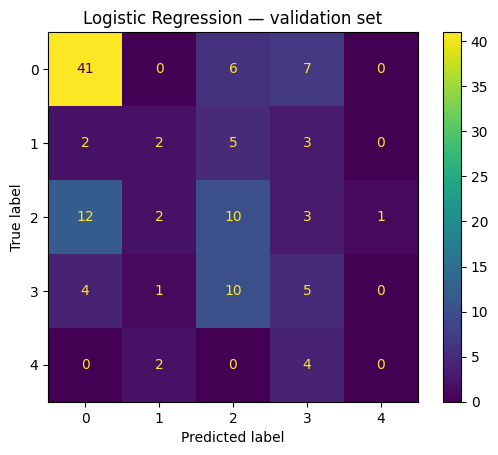

In [19]:
# Baseline model training

# Flatten the images, because sklearn models expects 1D feature vectors, not 2D images
def prepare_sklearn_data(dataset) :
    images = np.stack([np.array(dataset[i][0]) for i in range(len(dataset))])
    labels = np.array([dataset[i][1].item() for i in range(len(dataset))])
    # flatten each image from (28, 28, 3) to (2352)
    images = images.reshape(len(dataset), -1)
    # normalize to [0, 1]
    images = images / 255.0
    return images, labels

# Create new flat datasets with normalized pixel values
X_train, y_train = prepare_sklearn_data(train_data_raw)
X_val,   y_val   = prepare_sklearn_data(val_data_raw)
X_test,  y_test  = prepare_sklearn_data(test_data_raw)

# Train a logistic regression model - LR val accuracy: 0.4833

model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)

val_preds = model.predict(X_val)
val_acc = accuracy_score(y_val, val_preds)
print(f"LR val accuracy: {val_acc:.4f}")

# Train a random forest model - RF val accuracy: 0.4917
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

rf_val_preds = rf_model.predict(X_val)
rf_val_acc = accuracy_score(y_val, rf_val_preds)
print(f"RF val accuracy: {rf_val_acc:.4f}")


# Plot confusion matrix that displays the correct classification of samples predicted for each class (X) vs the true class labels (y)
cm = confusion_matrix(y_val, val_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0,1,2,3,4])
disp.plot()
plt.title("Logistic Regression — validation set")
plt.show()